# **Tutorial 2: Mengambil Rerata**

oleh: Jihan A. As-sya'bani (jihan.ahmad.a@mail.ugm.ac.id)

Jalankan sel berikut sebelum memulai:

In [1]:
# library untuk mengolah data sebagai tabel:
import pandas as pd 

# library untuk membuat plot:
import matplotlib.pyplot as plt

Data mentah dari metmast memiliki resolusi 1 detik atau frekuensi sampling 1 Hz. Namun cup anemometer yang terpasang memiliki frekuensi yang lebih rendah dan memiliki perekaman data dengan kelipatan 1,25 m/detik. Oleh karena itu data tampak aneh dan tidak dapat langsung digunakan. Di sisi lain, data resolusi detik juga seringkali menyebabkan ukuran file terlalu besar untuk periode pengukuran 1 tahun. 

Jalankan sel berikut untuk membaca data bulan November 2025 dan melihat isi tabel secara cepat:

In [2]:
# mendefinisikan path file data:
path = "LBN_2025_11.parquet"

# membaca data sebagai dataframe df:
df = pd.read_parquet(path)

# melihat isi df:
df 

,time,record_no,wdir_15m,wspd_10m,wspd_15m
0,2025-11-01 00:00:00,8830830,6.418,0.00,0.00
1,2025-11-01 00:00:01,8830831,5.980,1.25,1.25
2,2025-11-01 00:00:02,8830832,6.418,0.00,1.25
3,2025-11-01 00:00:03,8830833,7.488,0.00,1.25
4,2025-11-01 00:00:04,8830834,9.140,1.25,1.25
...,...,...,...,...,...
2439239,2025-11-30 23:59:55,11422825,312.400,1.25,1.25
2439240,2025-11-30 23:59:56,11422826,313.000,1.25,1.25
2439241,2025-11-30 23:59:57,11422827,327.100,0.00,0.00
2439242,2025-11-30 23:59:58,11422828,332.100,1.25,1.25


Jalankan sel di bawah ini untuk melakukan menampilkan data pengukuran di ketinggian sebagai plot cepat:

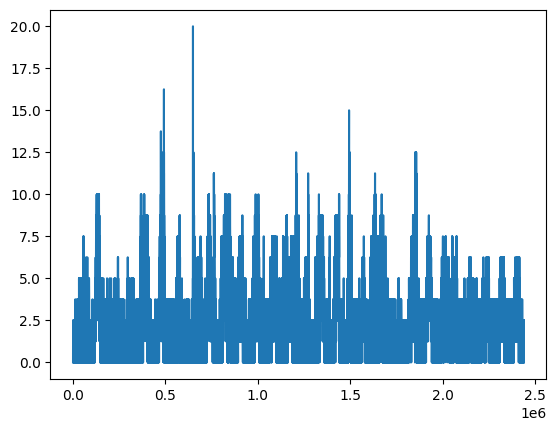

In [3]:
plt.plot(df["wspd_15m"])

Agar dapat dianalisis lebih lanjut, data mentah ini perlu diambil rerata sesuai kebutuhan. Beberapa 
- 10-menit, standard rekomendasi IEC untuk: 
	- Estimasi produksi energi tahunan. 
	- Analisis ombak (_wake_) dan optimisasi tata letak kebun angin

- 1-jam, digunakan untuk: 
	- analisis korelasi dengan data reanalisis skala meso (ERA5, MERRA-2, BARRA2, dll.)
	- proyeksi produksi energi jangka panjang. 

- 1-bulan, digunakan untuk:
	- analisis karakter musiman potensi angin

Pandas memiliki fitur yang memudahkan untuk mendapatkan nilai rerata ini, yaitu `resample`. Namun, hal ini hanya dapat dilakukan apabila data merupakan data timeseries. Untuk melakukannya, kita perlu menggunakan kolom yang menunjukkan waktu perekaman data sebagai indeks.

## **2.1. Rerata 10-menit**

Jalankan sel berikut untuk melakukan resample ke 10-menit:

In [4]:
# gunakan kolom "time" sebagai indeks:
df = df.set_index("time")

df

,record_no,wdir_15m,wspd_10m,wspd_15m
time,,,,
2025-11-01 00:00:00,8830830,6.418,0.00,0.00
2025-11-01 00:00:01,8830831,5.980,1.25,1.25
2025-11-01 00:00:02,8830832,6.418,0.00,1.25
2025-11-01 00:00:03,8830833,7.488,0.00,1.25
2025-11-01 00:00:04,8830834,9.140,1.25,1.25
...,...,...,...,...
2025-11-30 23:59:55,11422825,312.400,1.25,1.25
2025-11-30 23:59:56,11422826,313.000,1.25,1.25
2025-11-30 23:59:57,11422827,327.100,0.00,0.00


Sekarang, dapatkan dataframe yang berisi nilai rerata (mean) per 10 menit sebagai `df_10min`:

In [5]:
# resample ke 10 menit:
df_10min = df.resample("10min").agg("mean")
df_10min

,record_no,wdir_15m,wspd_10m,wspd_15m
time,,,,
2025-11-01 00:00:00,8831129.5,159.657810,0.416667,0.862500
2025-11-01 00:10:00,8831729.5,13.029583,0.010417,0.083333
2025-11-01 00:20:00,8832329.5,126.228163,0.289583,0.300000
2025-11-01 00:30:00,8832929.5,321.900833,0.362500,0.597917
2025-11-01 00:40:00,8833529.5,105.190877,0.227083,0.620833
...,...,...,...,...
2025-11-30 23:10:00,11420129.5,321.628553,0.554167,1.070833
2025-11-30 23:20:00,11420729.5,301.103343,0.468750,1.041667
2025-11-30 23:30:00,11421329.5,319.894903,0.343750,0.970833


Text(0.5, 1.0, 'Rerata 10-menit Kecepatan Angin')

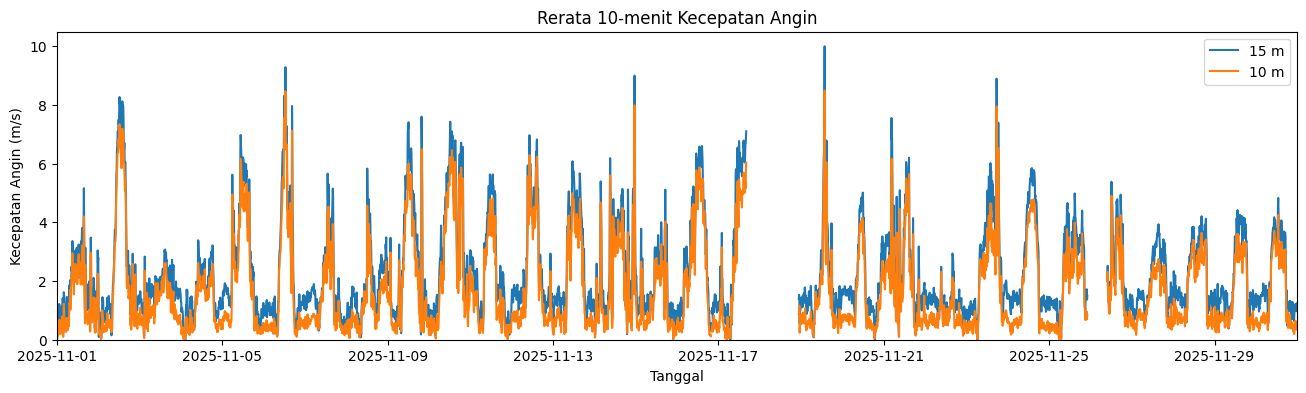

In [6]:
# Membuat plot rasio dimensi 16 x 4:
plt.figure(figsize=(16,4))

# Membuat plot data kecepatan angin:
plt.plot(df_10min.index, df_10min["wspd_15m"], label="15 m") # data ketinggian 15m
plt.plot(df_10min.index, df_10min["wspd_10m"], label="10 m") # data ketinggian 10m

# Mengatur batas nilai sumbu-x
plt.xlim(df_10min.index.min(), df_10min.index.max()) # indeks terkecil sampai terbesar

# Mengatur batas nilai sumbu-y
plt.ylim(0, 10.5) # dari 0 sampai 10.5 m/s

# Label sumbu x:
plt.xlabel("Tanggal")

# Label sumbu y:
plt.ylabel("Kecepatan Angin (m/s)")
plt.legend()

# Judul plot:
plt.title("Rerata 10-menit Kecepatan Angin")

### **Menyimpan hasil pererataan sebagai data csv atau excel**

Data yang sudah direrata dapat diekspor ke format lain yang dapat langsung dibaca menggunakan perangkat lunak spread sheet seperti Microsoft Excel, misalnya csv atau xlsx. Keduanya menggunakan perintah yang berbeda:
- Ekspor ke csv: `df.to_csv("nama_file.csv")`
- Ekspor ke xlsx: `df.to_excel("nama_file.xlsx")`

Ganti `df` pada perintah di atas dengan variabel dataframe yang ingin diekspor, misalnya `df_10min`. 

Jalankan sel berikut untuk mengekspor dataframe yang berisi data rerata 10 menit ke csv:

In [7]:
# Mengekspor df_10min ke format csv:
export_file_name = "LBN_2025_11_10min.csv"
df_10min.to_csv(export_file_name)
print(f"Berhasil mengekspor {export_file_name}!")

Berhasil mengekspor LBN_2025_11_10min.csv!


## **2.2. Rerata 1 jam**

Dengan cara yang sama kita bisa mengambil nilai rerata per jam dengan menggunakan `"1h"` sebagai kata kunci saat melakukan resample.

In [8]:
df_1h = df.resample("1h").agg("mean")
df_1h

,record_no,wdir_15m,wspd_10m,wspd_15m
time,,,,
2025-11-01 00:00:00,8832629.5,126.376604,0.245139,0.490972
2025-11-01 01:00:00,8836229.5,251.629092,0.531597,1.083333
2025-11-01 02:00:00,8839829.5,273.671285,0.417014,0.860764
2025-11-01 03:00:00,8843429.5,290.881265,0.630903,1.036806
2025-11-01 04:00:00,8847029.5,257.454991,0.717708,1.133333
...,...,...,...,...
2025-11-30 19:00:00,11406629.5,270.744443,0.698264,1.212153
2025-11-30 20:00:00,11410229.5,211.223312,0.503472,1.000347
2025-11-30 21:00:00,11413829.5,302.160630,0.429861,0.975000


Text(0.5, 1.0, 'Rerata 1-jam Kecepatan Angin')

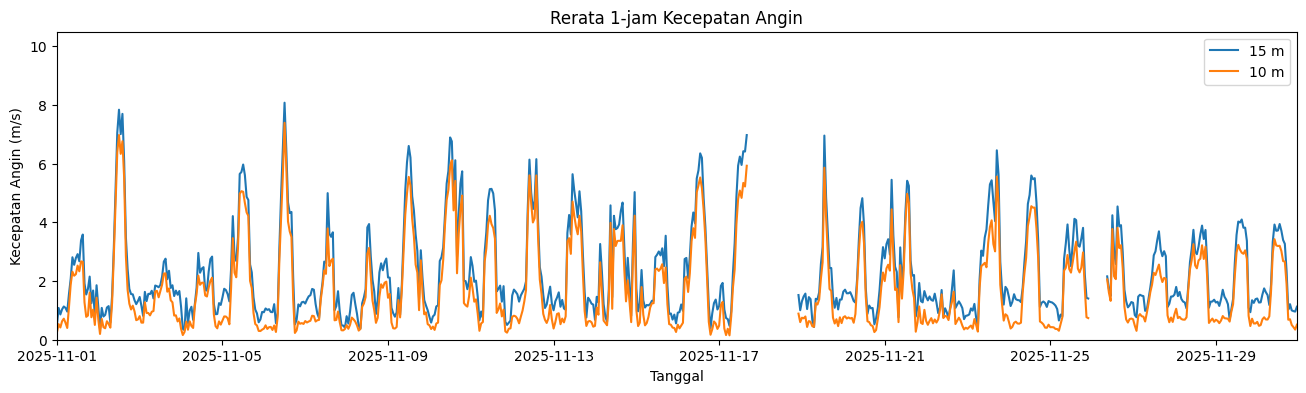

In [9]:
# Membuat plot rasio dimensi 16 x 4:
plt.figure(figsize=(16,4))

# Membuat plot data kecepatan angin:
plt.plot(df_1h.index, df_1h["wspd_15m"], label="15 m") # data ketinggian 15m
plt.plot(df_1h.index, df_1h["wspd_10m"], label="10 m") # data ketinggian 10m

# Mengatur batas nilai sumbu-x
plt.xlim(df_1h.index.min(), df_1h.index.max()) # indeks terkecil sampai terbesar

# Mengatur batas nilai sumbu-y
plt.ylim(0, 10.5) # dari 0 sampai 10.5 m/s

# Label sumbu x:
plt.xlabel("Tanggal")

# Label sumbu y:
plt.ylabel("Kecepatan Angin (m/s)")
plt.legend()

# Judul plot:
plt.title("Rerata 1-jam Kecepatan Angin")

## **2.3. Rerata Harian**

Dengan cara yang sama kita bisa mengambil nilai rerata harian dengan menggunakan `"1d"` sebagai kata kunci saat melakukan resample.

In [10]:
df_1d = df.resample("1d").agg("mean")
df_1d

,record_no,wdir_15m,wspd_10m,wspd_15m
time,,,,
2025-11-01,8.874030e+06,230.918314,1.318851,1.831062
2025-11-02,8.960430e+06,180.334089,2.290712,2.793229
2025-11-03,9.046830e+06,190.517956,1.235851,1.744473
2025-11-04,9.133230e+06,209.883123,1.069010,1.516913
2025-11-05,9.219630e+06,277.581277,2.133840,2.768229
2025-11-06,9.306030e+06,278.435259,1.880006,2.474450
2025-11-07,9.392430e+06,214.119324,1.230802,1.771470
2025-11-08,9.478830e+06,248.847280,1.223712,1.750680
2025-11-09,9.565230e+06,246.252859,2.157104,2.745616


Text(0.5, 1.0, 'Rerata 1 hari Kecepatan Angin')

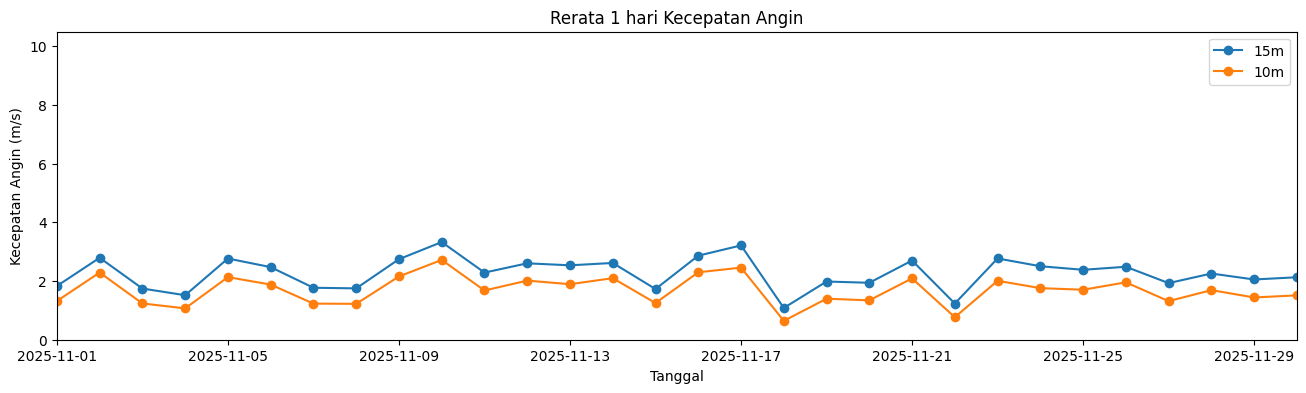

In [11]:
# Membuat plot rasio dimensi 16 x 4:
plt.figure(figsize=(16,4))

# Membuat plot data kecepatan angin:
plt.plot(df_1d.index, df_1d["wspd_15m"], 'o-', label="15m") # data ketinggian 15m
plt.plot(df_1d.index, df_1d["wspd_10m"], 'o-', label="10m") # data ketinggian 10m

# Mengatur batas nilai sumbu-x
plt.xlim(df_1d.index.min(), df_1d.index.max()) # indeks terkecil sampai terbesar

# Mengatur batas nilai sumbu-y
plt.ylim(0, 10.5) # dari 0 sampai 10.5 m/s

# Label sumbu x:
plt.xlabel("Tanggal")

# Label sumbu y:
plt.ylabel("Kecepatan Angin (m/s)")

# Menampilkan legenda:
plt.legend()

# Judul plot:
plt.title("Rerata 1 hari Kecepatan Angin")

## **2.4. Ringkasan**

#### 2.4.1. Skrip lengkap untuk membaca, mengambil rerata, dan mengekspor hasil rerata:

In [ ]:
import pandas as pd 

# mendefinisikan path file data:
path = "LBN_2025_11.parquet"

# membaca data sebagai dataframe df:
df = pd.read_parquet(path)

# gunakan kolom "time" sebagai indeks:
df = df.set_index("time")

# mengambil rerata 10 menit:
df_10min = df.resample("10min").agg("mean")

# Mengekspor df_10min ke format csv:
export_file_name = "LBN_2025_11_10min.csv"
df_10min.to_csv(export_file_name)
print(f"Berhasil mengekspor {export_file_name}!")


#### 2.4.2. Menampilkan perbandingan ketiga nilai rerata

Text(0.5, 1.0, 'Perbandingan Rerata Kecepatan Angin di Ketinggian 15m')

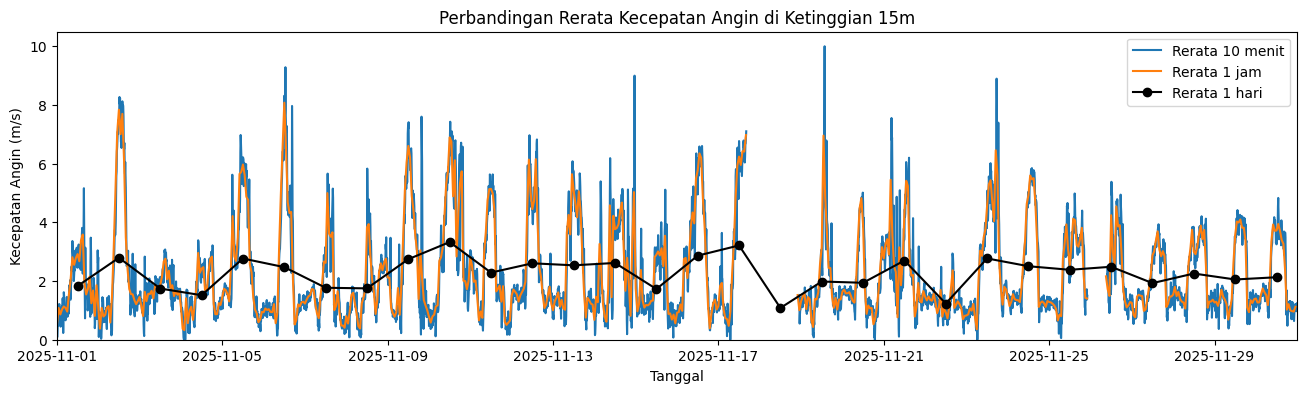

In [12]:
# Membuat plot rasio dimensi 16 x 4:
plt.figure(figsize=(16,4))

# Membuat plot data kecepatan angin:
plt.plot(df_10min.index, df_10min["wspd_15m"], label="Rerata 10 menit") # data ketinggian 15m
plt.plot(df_1h.index, df_1h["wspd_15m"], label="Rerata 1 jam") # data ketinggian 10m
plt.plot(df_1d.index+pd.Timedelta("12h"), df_1d["wspd_15m"], 'o-', c='k', label="Rerata 1 hari") # data ketinggian 15m

# Mengatur batas nilai sumbu-x
plt.xlim(df_10min.index.min(), df_10min.index.max()) # indeks terkecil sampai terbesar

# Mengatur batas nilai sumbu-y
plt.ylim(0, 10.5) # dari 0 sampai 10.5 m/s

# Label sumbu x:
plt.xlabel("Tanggal")

# Label sumbu y:
plt.ylabel("Kecepatan Angin (m/s)")

# Menampilkan legenda:
plt.legend()

# Judul plot:
plt.title("Perbandingan Rerata Kecepatan Angin di Ketinggian 15m")